In [4]:
import torch
import torchvision
import torchvision.transforms as transforms

In [5]:
#加载和归一化CIFAR10
transform=transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))]
)
batch_size=4
trainset=torchvision.datasets.CIFAR10(root='./data',train=True,
                                       download=True,transform=transform)
trainloader=torch.utils.data.DataLoader(trainset,batch_size=batch_size,shuffle=True,num_workers=2)
testset=torchvision.datasets.CIFAR10(root='./data',train=False,download=True,transform=transform)
testloader=torch.utils.data.DataLoader(testset,batch_size=batch_size,shuffle=False,num_workers=2)

classes=('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

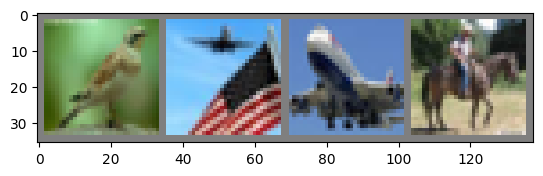

bird  plane plane horse


In [6]:
#吧加载到的图片画出来
import matplotlib.pyplot as plt
import numpy as np

#显示图像的函数
def imshow(img):
    #解标准化unnormalize
    img=img/2 + 0.5
    npimg=img.numpy()#变成numpy才能使用下面的np.transpose翻转函数
    plt.imshow(np.transpose(npimg,(1,2,0)))#在pytoch和在matplotlib图片的维度顺序不同
    plt.show()

dataiter=iter(trainloader) # 创建迭代器
images,labels=next(dataiter) # 获取一批次（Batch）数据

# show images
imshow(torchvision.utils.make_grid(images)) 
# 函数torchvison.utils.make_grid()是将你拿的一个批次(4张图片)的小图拼接成一个大图，中间留缝隙

#打印标签 print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

    

In [7]:
# 定义卷积神经网络
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1=nn.Conv2d(3,6,5) #卷积第一层
        self.pool=nn.MaxPool2d(2,2) #池化
        self.conv2=nn.Conv2d(6,16,5) #卷积第二层
        self.fc1=nn.Linear(16*5*5,120) #全连接层
        self.fc2=nn.Linear(120,84)
        self.fc3=nn.Linear(84,10)
    #前向传播
    def forward(self,x):
        x=self.pool(F.relu(self.conv1(x)))#卷积->激活->池化
        x=self.pool(F.relu(self.conv2(x)))#卷积->激活->池化
        x=torch.flatten(x,1)#展平做全连接层
        x=F.relu(self.fc1(x))
        x=F.relu(self.fc2(x))
        x=self.fc3(x)
        return x

net=Net()

In [8]:
#定义损失函数和优化器，准备反向传播
import torch.optim as optim
criterion=nn.CrossEntropyLoss() #多元交叉熵损失函数
optimizer=optim.SGD(net.parameters(),lr=0.001,momentum=0.9)#随机下降梯度优化算法，保持0.9的动量

In [ ]:
#训练网络，对数据集进行多次循环,这个步骤需要2分钟
for epoch in range(2):
    running_loss=0.0
    for i,data in enumerate(trainloader,0):
        inputs,labels =data
        optimizer.zero_grad()
        outputs=net(inputs)
        loss=criterion(outputs,labels)
        loss.backward()#反向传播
        optimizer.step()#更新

        #打印损失
        running_loss+=loss.item()
        if i%2000==1999:
            print(f'[{epoch+1},{i+1:5d}] loss:{running_loss/2000:.3f}')
            running_loss=0.0

print('Finished Training')

[1, 2000] loss:2.235
[1, 4000] loss:1.925
[1, 6000] loss:1.693
[1, 8000] loss:1.582
[1,10000] loss:1.530
[1,12000] loss:1.466
[2, 2000] loss:1.403
[2, 4000] loss:1.359
[2, 6000] loss:1.358
[2, 8000] loss:1.327
[2,10000] loss:1.305
[2,12000] loss:1.297
Finished Training


In [10]:
#快速保存好训练好的模型
PATH='./cifar_net.pth'
torch.save(net.state_dict(),PATH)

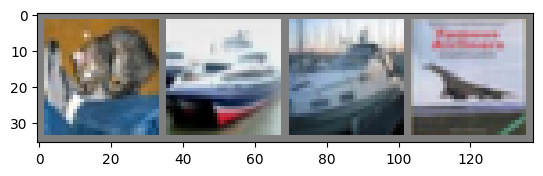

GroundTruth: cat   ship  ship  plane


In [11]:
#在测试数据上测试网络

#先挑选出一批次测试集图像，打印输出原图像和原标签
dataiter=iter(testloader)
images,labels=next(dataiter)

imshow(torchvision.utils.make_grid(images))
print('GroundTruth:',' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [12]:
#加载回之前保存的模型
net=Net()
net.load_state_dict(torch.load(PATH,weights_only=True))

<All keys matched successfully>

In [13]:
#模型测试上面的测试集
outputs=net(images)
_,predicted=torch.max(outputs,1)
print('Predicted:',' '.join(f'{classes[predicted[j]]:5s}' for j in range(4)))


Predicted: cat   ship  ship  ship 
